In [2]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict,Annotated
from langchain_core.messages import BaseMessage,HumanMessage


c:\Users\yashb\OneDrive\Desktop\langGraph_tutorials\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [9]:
from langgraph.checkpoint.memory import MemorySaver

In [3]:
from langgraph.graph.message import add_messages
#defining a state
# 4 typed of messages are inherited rom basemessage
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]

In [4]:
llm = ChatOpenAI() # default model
def chatNode(state:ChatState):

    #take user query from state
    messages = state["messages"]

    # send to llm 
    response = llm.invoke(messages)

    # response store in state
    return {'messages':[response]}

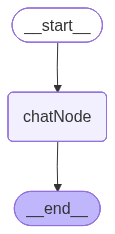

In [ ]:
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

graph.add_node("chatNode",chatNode)
graph.add_edge(START,"chatNode")
graph.add_edge("chatNode",END)
workflow = graph.compile(checkpointer=checkpointer)

workflow

In [ ]:
thread_id = '1'

while True:

    user_message= input('Type Here')
    print('User: ',user_message)
    if user_message.strip().lower() in ['exit','quit','bye']:
        break

    config = {'configurable': {'thread_id':thread_id}}
    response = workflow.invoke({'messages': [HumanMessage(content = user_message)]},config=config)

    print("AI: ",response['messages'][-1].content)